# Emotion Prediction on DistilRoBERTa
[michellejieli/emotion_text_classifier](https://huggingface.co/michellejieli/emotion_text_classifier)

In [62]:
import os
import pandas as pd
import torch
import wandb
from datasets import load_dataset, Dataset
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline
from huggingface_hub import login
from peft import LoraConfig, get_peft_model

In [28]:
# prevent env load failed
%load_ext dotenv
%dotenv

The dotenv extension is already loaded. To reload it, use:
  %reload_ext dotenv


In [29]:
login(token=os.environ.get("HF_TOKEN", ""), add_to_git_credential=True)
wandb.login(key=os.environ.get("WANDB_API_KEY", ""), relogin=True)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Token is valid (permission: write).
Your token has been saved in your configured git credential helpers (cache).
Your token has been saved to /home/user/.cache/huggingface/token
Login successful


True

In [30]:
# Initialize Wandb
wandb_config = {
    "base_model": "michellejieli/emotion_text_classifier",
}
wandb.init(
    job_type="fine-tuning",
    config=wandb_config,
    project="emotion-chat-bot-ncu",
    group="candidate_generation",
    mode="online",
    # resume="auto"
)

# data preprocessing
把 label 向後平移一個

In [31]:
# Model from Hugging Face hub
base_model = "michellejieli/emotion_text_classifier"

# Saved fine-tuned model 
new_model = "test_model"

In [32]:
def preprocessing(data):
    data = data.rename_column("utterance", "text")
    data = data.rename_column("emotion", "label")
    data = data.remove_columns("turn_type")
    # data = data.remove_columns(["dialog_id", "turn_type"])
    return data

def shifting_test(data):
    df = data.to_pandas()
    df["label"] = df.groupby('dialog_id')["label"].shift(-1)
    df.dropna(inplace = True)
    df["label"]  = df["label"].astype(int)
    print(df.head(20))
    modified_dataset = Dataset.from_pandas(df)
    data = modified_dataset
    return data

def shifting_train(data):
    df = data["train"].to_pandas()
    df["label"] = df.groupby('dialog_id')["label"].shift(-1)
    df.dropna(inplace = True)
    df["label"]  = df["label"].astype(int)
    modified_dataset = Dataset.from_pandas(df)
    data["train"] = modified_dataset
    return data

def shift_labels(dataset):
    df = dataset.to_pandas()
    df["label"] = df.groupby('dialog_id')["label"].shift(-1)
    df.dropna(inplace = True)
    df["label"]  = df["label"].astype(int)
    # print(df.head(20))
    return dataset.from_pandas(df)


def shift_all(data):
    data["train"] = shift_labels(data["train"])
    data["validation"] = shift_labels(data["validation"])
    data["test"] = shift_labels(data["test"])
    
    return data

In [33]:
data_name = "benjaminbeilharz/better_daily_dialog"
# data_raw = load_dataset(data_name, num_proc=16)
data_raw = load_dataset(data_name, num_proc=16)
data_raw = preprocessing(data_raw)
data_raw



DatasetDict({
    train: Dataset({
        features: ['dialog_id', 'text', 'label'],
        num_rows: 87170
    })
    validation: Dataset({
        features: ['dialog_id', 'text', 'label'],
        num_rows: 8069
    })
    test: Dataset({
        features: ['dialog_id', 'text', 'label'],
        num_rows: 7740
    })
})

In [34]:
# test_data = load_dataset(data_name, split='test', num_proc=8)
# test_data = preprocessing(data_raw["test"])
test_data = shifting_test(data_raw["test"])
test_data


    dialog_id                                               text  label
0           0               Hey man , you wanna buy some weed ?       6
1           0                                       Some what ?       0
2           0   Weed ! You know ? Pot , Ganja , Mary Jane som...      0
3           0                            Oh , umm , no thanks .       0
4           0   I also have blow if you prefer to do a few li...      0
5           0                           No , I am ok , really .       0
6           0   Come on man ! I even got dope and acid ! Try ...      0
7           0   Do you really have all of these drugs ? Where...      0
8           0   I got my connections ! Just tell me what you ...      0
9           0              Sounds good ! Let ’ s see , I want .       3
10          0                                            Yeah ?       0
12          1            The taxi drivers are on strike again .       0
13          1                                        What for ? 

Dataset({
    features: ['dialog_id', 'text', 'label', '__index_level_0__'],
    num_rows: 6740
})

In [35]:
data = data_raw

In [36]:
# 获取原始训练集
train_dataset = data["train"]

# 计算提取的前10%的数量
# num_samples = int(len(train_dataset) * 0.01)

# 提取前10%的数据
train_10_percent = train_dataset.select(range(1000))

# 更新DatasetDict中的训练集
data["train"] = train_10_percent

# 打印修改后的DatasetDict
print(data)


DatasetDict({
    train: Dataset({
        features: ['dialog_id', 'text', 'label'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['dialog_id', 'text', 'label'],
        num_rows: 8069
    })
    test: Dataset({
        features: ['dialog_id', 'text', 'label'],
        num_rows: 7740
    })
})


In [37]:
# df = data["train"].to_pandas()
# df["label"] = df.groupby('dialog_id')["label"].shift(-1)
# print(df.head(20))

In [38]:
# df.dropna(inplace = True)
# df["label"]  = df["label"].astype(int)
# print(df.head(20))

In [39]:
shift_all(data)

DatasetDict({
    train: Dataset({
        features: ['dialog_id', 'text', 'label', '__index_level_0__'],
        num_rows: 858
    })
    validation: Dataset({
        features: ['dialog_id', 'text', 'label', '__index_level_0__'],
        num_rows: 7069
    })
    test: Dataset({
        features: ['dialog_id', 'text', 'label', '__index_level_0__'],
        num_rows: 6740
    })
})

In [40]:
# shifting_train(data)

In [41]:
data["train"]["label"][0:20]

[0, 0, 0, 0, 0, 4, 4, 4, 4, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [42]:
data["validation"]["label"][0:20]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [43]:
tokenizer = AutoTokenizer.from_pretrained(base_model)

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True)

In [44]:
emotions = data
print(tokenize(emotions["train"][:2]))

{'input_ids': [[0, 34673, 2156, 2488, 2156, 141, 59, 164, 13, 10, 367, 16328, 71, 3630, 17487, 1437, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [45]:
#hide_input
#not very sure what did he do here
tokens2ids = list(zip(tokenizer.all_special_tokens, tokenizer.all_special_ids))
data = sorted(tokens2ids, key=lambda x: x[-1])
df = pd.DataFrame(data, columns=["Special Token", "Special Token ID"])
df.T

,0,1,2,3,4
Special Token,<s>,<pad>,</s>,<unk>,<mask>
Special Token ID,0,1,2,3,50264


In [46]:
 # hide_output
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)
print(emotions_encoded.column_names)

Map:   0%|          | 0/858 [00:00<?, ? examples/s]

Map:   0%|          | 0/7069 [00:00<?, ? examples/s]

Map:   0%|          | 0/6740 [00:00<?, ? examples/s]

{'train': ['dialog_id', 'text', 'label', '__index_level_0__', 'input_ids', 'attention_mask'], 'validation': ['dialog_id', 'text', 'label', '__index_level_0__', 'input_ids', 'attention_mask'], 'test': ['dialog_id', 'text', 'label', '__index_level_0__', 'input_ids', 'attention_mask']}


In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# hide_output
num_labels = 7
id2label = {
    0: "neutral",
    1: "anger",
    2: "disgust",
    3: "fear",
    4: "happiness",
    5: "sadness",
    6: "surprise"
}

label2id = {
    "neutral": 0,
    "anger": 1,
    "disgust": 2,
    "fear": 3,
    "happiness": 4,
    "sadness": 5,
    "surprise": 6
}

model = AutoModelForSequenceClassification.from_pretrained(base_model, num_labels=num_labels, id2label=id2label, label2id=label2id)

In [63]:
lora_config = LoraConfig(
    lora_alpha=16,
    lora_dropout=0.1,
    r=8,
    bias="none",
    task_type="SEQ_CLS",
    use_rslora = True
)

In [65]:
peft_model = get_peft_model(model, lora_config)

In [48]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

## Train

In [49]:
batch_size = 64
logging_steps = len(emotions_encoded["train"]) // batch_size

In [58]:
training_args = TrainingArguments(
    output_dir="./checkpoints",
    num_train_epochs=10,
    load_best_model_at_end = True,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=1,
    optim="paged_adamw_32bit",
    save_steps=100,
    save_strategy = "epoch",
    logging_steps=logging_steps,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=False,
    bf16=False,
    max_grad_norm=0.3,
    max_steps=-1,
    warmup_ratio=0.03,
    group_by_length=True,
    lr_scheduler_type="constant",
    report_to=["wandb"],
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": True},
    evaluation_strategy="epoch",
    log_level="error",
    overwrite_output_dir=True
)

In [59]:
wandb.config["trainer_arguments"] = training_args.to_dict()

In [69]:
trainer = Trainer(model=peft_model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotions_encoded["train"],
                  eval_dataset=emotions_encoded["validation"],
                  tokenizer=tokenizer)
# trainer.train(resume_from_checkpoint=True);
# trainer.model.save_pretrained(new_model)


/home/user/.cache/pypoetry/virtualenvs/chat-bot-20tW9agt-py3.11/lib/python3.11/site-packages/accelerate/accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


In [55]:
# trainer.args.num_train_epochs = trainer.args.num_train_epochs + 5

In [72]:
trainer.train()

{'loss': 0.2244, 'grad_norm': 3.923689365386963, 'learning_rate': 2e-05, 'epoch': 0.93}
{'eval_loss': 1.1095221042633057, 'eval_accuracy': 0.8136935917385769, 'eval_f1': 0.8148832527224109, 'eval_runtime': 28.9179, 'eval_samples_per_second': 244.451, 'eval_steps_per_second': 3.838, 'epoch': 1.0}
{'loss': 0.1733, 'grad_norm': 2.7708303928375244, 'learning_rate': 2e-05, 'epoch': 1.86}
{'eval_loss': 1.1105092763900757, 'eval_accuracy': 0.806337530060829, 'eval_f1': 0.8107872272587747, 'eval_runtime': 28.7962, 'eval_samples_per_second': 245.484, 'eval_steps_per_second': 3.855, 'epoch': 2.0}
{'loss': 0.1842, 'grad_norm': 4.801100730895996, 'learning_rate': 2e-05, 'epoch': 2.79}
{'eval_loss': 1.099576473236084, 'eval_accuracy': 0.8069033809591173, 'eval_f1': 0.8112977783554128, 'eval_runtime': 30.0024, 'eval_samples_per_second': 235.615, 'eval_steps_per_second': 3.7, 'epoch': 3.0}
{'loss': 0.2034, 'grad_norm': 5.562992095947266, 'learning_rate': 2e-05, 'epoch': 3.71}
{'eval_loss': 1.08177113

TrainOutput(global_step=140, training_loss=0.18856229782104492, metrics={'train_runtime': 419.0033, 'train_samples_per_second': 20.477, 'train_steps_per_second': 0.334, 'train_loss': 0.18856229782104492, 'epoch': 10.0})

In [ ]:
# model = AutoModelForSequenceClassification.from_pretrained(base_model, num_labels=num_labels, id2label=id2label, label2id=label2id)
# trainer1 = Trainer(model=model, args=training_args,
#                   compute_metrics=compute_metrics,
#                   train_dataset=emotions_encoded["train"],
#                   eval_dataset=emotions_encoded["validation"],
#                   tokenizer=tokenizer)

In [ ]:
# import matplotlib.pyplot as plt
# f1_scores = []
# accuracies = []

# for i in range(2):
#     model = AutoModelForSequenceClassification.from_pretrained(new_model, num_labels=num_labels, id2label=id2label, label2id=label2id)
#     trainer1 = Trainer(model=model, args=training_args,
#               compute_metrics=compute_metrics,
#               train_dataset=emotions_encoded["train"],
#               eval_dataset=emotions_encoded["validation"],
#               tokenizer=tokenizer)
#     trainer1.train()
#     # print("finished an epoch")
#     trainer1.model.save_pretrained(new_model)
#     # print("saved")
#     # classifier_model = AutoModelForSequenceClassification.from_pretrained(new_model, num_labels=num_labels, id2label=id2label, label2id=label2id)
#     classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=0)
#     def predict(row):
#         text = row['text']
#         true_label = row['label']
#         predicted_result = classifier(text)[0]
#         predicted_label = label2id[predicted_result["label"]]
#         return {"predicted_label": predicted_label, "true_label": true_label}

#     predictions = test_data.map(predict)
#     true_labels = [p["true_label"] for p in predictions]
#     predicted_labels = [p["predicted_label"] for p in predictions]

#     f1 = f1_score(true_labels, predicted_labels, average='weighted')
#     accuracy = accuracy_score(true_labels, predicted_labels)

#     print("F1-score:", f1, )
#     print("Accuracy:", accuracy)
    
#     f1_scores.append(f1)
#     accuracies.append(accuracy)

/home/user/.cache/pypoetry/virtualenvs/chat-bot-20tW9agt-py3.11/lib/python3.11/site-packages/accelerate/accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


{'loss': 0.0265, 'grad_norm': 46.533294677734375, 'learning_rate': 2e-05, 'epoch': 0.99}
{'eval_loss': 1.8082133531570435, 'eval_accuracy': 0.8033213533275498, 'eval_f1': 0.8117036403755897, 'eval_runtime': 31.6162, 'eval_samples_per_second': 255.217, 'eval_steps_per_second': 4.017, 'epoch': 1.0}
{'train_runtime': 152.7065, 'train_samples_per_second': 49.356, 'train_steps_per_second': 0.773, 'train_loss': 0.027863183895410117, 'epoch': 1.0}


Map:   0%|          | 0/6740 [00:00<?, ? examples/s]

/home/user/.cache/pypoetry/virtualenvs/chat-bot-20tW9agt-py3.11/lib/python3.11/site-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(


F1-score: 0.7503810370892451
Accuracy: 0.7562314540059347


/home/user/.cache/pypoetry/virtualenvs/chat-bot-20tW9agt-py3.11/lib/python3.11/site-packages/accelerate/accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


{'loss': 0.0264, 'grad_norm': 44.92800521850586, 'learning_rate': 2e-05, 'epoch': 0.99}
{'eval_loss': 2.0479846000671387, 'eval_accuracy': 0.7765522369562523, 'eval_f1': 0.7958920706884176, 'eval_runtime': 31.7696, 'eval_samples_per_second': 253.985, 'eval_steps_per_second': 3.998, 'epoch': 1.0}
{'train_runtime': 145.4426, 'train_samples_per_second': 51.821, 'train_steps_per_second': 0.811, 'train_loss': 0.026745752699799456, 'epoch': 1.0}


Map:   0%|          | 0/6740 [00:00<?, ? examples/s]

/home/user/.cache/pypoetry/virtualenvs/chat-bot-20tW9agt-py3.11/lib/python3.11/site-packages/transformers/pipelines/base.py:1157: UserWarning: You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
  warnings.warn(


F1-score: 0.7424483109841707
Accuracy: 0.7381305637982196


Text(0, 0.5, 'Accuracy')

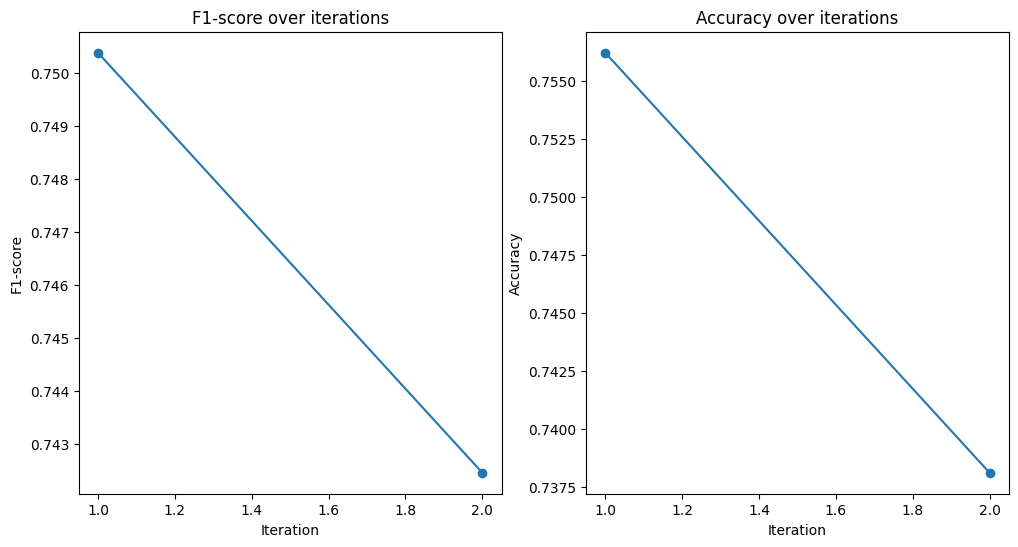

In [ ]:
# # 绘制 F1-score 和 Accuracy 的变化趋势
# plt.figure(figsize=(12, 6))

# plt.subplot(1, 2, 1)
# plt.plot(range(1, len(f1_scores) + 1), f1_scores, marker='o')
# plt.title('F1-score over iterations')
# plt.xlabel('Iteration')
# plt.ylabel('F1-score')

# plt.subplot(1, 2, 2)
# plt.plot(range(1, len(accuracies) + 1), accuracies, marker='o')
# plt.title('Accuracy over iterations')
# plt.xlabel('Iteration')
# plt.ylabel('Accuracy')

In [ ]:
wandb.finish()

# Inference
I use first five percent of train data to predict

In [ ]:
classifier_model = AutoModelForSequenceClassification.from_pretrained(new_model, num_labels=num_labels, id2label=id2label, label2id=label2id)

In [ ]:
classifier = pipeline("sentiment-analysis", model=classifier_model, tokenizer=tokenizer, device=0)
data_name = "benjaminbeilharz/better_daily_dialog"
data = load_dataset(data_name, split='test', num_proc=8)
data = preprocessing(data)

In [ ]:
data[0:10]

{'text': ['Hey man , you wanna buy some weed ? ',
  ' Some what ? ',
  ' Weed ! You know ? Pot , Ganja , Mary Jane some chronic ! ',
  ' Oh , umm , no thanks . ',
  ' I also have blow if you prefer to do a few lines . ',
  ' No , I am ok , really . ',
  ' Come on man ! I even got dope and acid ! Try some ! ',
  ' Do you really have all of these drugs ? Where do you get them from ? ',
  ' I got my connections ! Just tell me what you want and I ’ ll even give you one ounce for free . ',
  ' Sounds good ! Let ’ s see , I want . '],
 'label': [0, 6, 0, 0, 0, 0, 0, 0, 0, 0]}

In [ ]:
data = shifting_test(data)

In [ ]:
data[0:10]

{'text': ['Hey man , you wanna buy some weed ? ',
  ' Some what ? ',
  ' Weed ! You know ? Pot , Ganja , Mary Jane some chronic ! ',
  ' Oh , umm , no thanks . ',
  ' I also have blow if you prefer to do a few lines . ',
  ' No , I am ok , really . ',
  ' Come on man ! I even got dope and acid ! Try some ! ',
  ' Do you really have all of these drugs ? Where do you get them from ? ',
  ' I got my connections ! Just tell me what you want and I ’ ll even give you one ounce for free . ',
  ' Sounds good ! Let ’ s see , I want . '],
 'label': [6, 0, 0, 0, 0, 0, 0, 0, 0, 3]}

In [ ]:

def predict(row):
    text = row['text']
    true_label = row['label']
    predicted_result = classifier(text)[0]
    predicted_label = label2id[predicted_result["label"]]

    # print(f"Predicted: {predicted_label}, True: {true_label},        ##Text: {text}")
    return {"predicted_label": predicted_label, "true_label": true_label}
predictions = data.map(predict)
true_labels = [p["true_label"] for p in predictions]
predicted_labels = [p["predicted_label"] for p in predictions]

f1 = f1_score(true_labels, predicted_labels, average='weighted')
accuracy = accuracy_score(true_labels, predicted_labels)

print("F1-score:", f1, )
print("Accuracy:", accuracy)